# Challenge — Red neuronal con Keras 3
### Universidad EAFIT | SI3003 — Introducción a la Inteligencia Artificial

---

## Objetivo

En clase construimos una red neuronal de clasificación con **Keras 3**.

En este ejercicio vas a aplicar la misma receta sobre un dataset diferente:

> **Olivetti Faces**

El dataset contiene imágenes de rostros en escala de grises. El objetivo será identificar a cuál persona pertenece cada imagen.

No necesitas diseñar un pipeline de datos nuevo. La carga, división y visualización están resueltas.

Tu trabajo se concentra en completar las etapas principales de Keras:

```text
Datos
  ↓
Modelo
  ↓
Loss + Optimizer
  ↓
Entrenamiento
  ↓
Evaluación
  ↓
Predicción
```

---

## ¿Qué debes completar?

Las celdas marcadas con `# TODO` contienen espacios que debes completar.

El resto del código está preparado para que puedas concentrarte en los conceptos vistos en clase.


---
## 0. Importar librerías

Usaremos:

- **Keras 3** para construir y entrenar la red.
- **scikit-learn** para cargar Olivetti Faces y dividir los datos.
- **NumPy** para manipular arrays.
- **Matplotlib** para visualizar imágenes.


In [1]:
import os
os.environ.setdefault("KERAS_BACKEND", "tensorflow")

import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

SEED = 42
keras.utils.set_random_seed(SEED)

print(f"Keras version : {keras.__version__}")
print(f"Backend       : {keras.backend.backend()}")


I0000 00:00:1791420428.519969     375 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1791420429.492402     375 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Keras version : 3.15.1
Backend       : tensorflow


---
# 1. Dataset: Olivetti Faces

Olivetti Faces contiene:

- **400 imágenes**
- imágenes de **64 × 64 píxeles**
- escala de grises
- **40 personas**
- **10 imágenes por persona**

La etiqueta indica la identidad de la persona:

```text
0, 1, 2, ..., 39
```

Cada imagen ya viene representada con valores flotantes aproximadamente en el rango:

$$
[0,1]
$$

Por eso, en este ejercicio **no necesitamos normalizar dividiendo por 255**.


In [2]:
# Esta parte está resuelta.

faces = fetch_olivetti_faces(
    shuffle=True,
    random_state=SEED
)

X = faces.images
y = faces.target

print("X:", X.shape)
print("y:", y.shape)
print("Valor mínimo:", X.min())
print("Valor máximo:", X.max())
print("Número de clases:", len(np.unique(y)))


X: (400, 64, 64)
y: (400,)
Valor mínimo: 0.0
Valor máximo: 1.0
Número de clases: 40


## 1.1 Dividir entrenamiento y prueba

Como solo tenemos 10 imágenes por persona, debemos asegurarnos de que todas las identidades aparezcan tanto en entrenamiento como en prueba.

Usaremos una división **estratificada**:

```text
80% entrenamiento
20% prueba
```

La opción:

```python
stratify=y
```

mantiene la proporción de cada clase en ambos conjuntos.

Esta parte está resuelta.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nPersonas en train:", len(np.unique(y_train)))
print("Personas en test :", len(np.unique(y_test)))


X_train: (320, 64, 64)
X_test : (80, 64, 64)
y_train: (320,)
y_test : (80,)

Personas en train: 40
Personas en test : 40


## 1.1b Centrado de los datos (preprocesamiento)

Los píxeles ya están en `[0,1]`, así que **no** dividimos por 255. Sin embargo, al estar **todos los valores entre 0 y 1** (media ≈ 0.5, siempre positivos), las sumas que entran a la primera capa `Dense` son grandes y sesgadas, y con esta arquitectura *fully-connected* el entrenamiento **se estanca** (la accuracy no sube del azar, ≈ 2.5% = 1/40).

La solución estándar —sin cambiar la arquitectura, el optimizador ni las épocas— es **centrar** las entradas restando la media y dividiendo por la desviación estándar (estadísticas calculadas **solo con el train**). Esto deja las entradas con media 0 y escala comparable, y la red converge.


In [4]:
# Centrado/estandarización de las imágenes (estadísticas SOLO de train).
# Evita que el entrenamiento se estanque con entradas en [0,1] y media ~0.5.
train_mean = X_train.mean()
train_std = X_train.std()

X_train = ((X_train - train_mean) / train_std).astype("float32")
X_test = ((X_test - train_mean) / train_std).astype("float32")

print("Media train (después):", round(float(X_train.mean()), 4))
print("Std train   (después):", round(float(X_train.std()), 4))


Media train (después): -0.0
Std train   (después): 1.0


### Pregunta 1

Cada imagen tiene tamaño:

$$
64 \times 64
$$

Cuando apliquemos `Flatten()`, ¿cuántos valores tendrá cada ejemplo?

**Respuesta:** **4096.** Cada rostro es $64\times64 = 4096$ píxeles en escala de grises, así que `Flatten()` produce un vector de **4096** valores por ejemplo.


---
## 1.2 Visualizar algunas imágenes

Esta parte está resuelta.

Observa que varias fotografías corresponden a la misma persona con pequeñas variaciones de expresión, iluminación y orientación.


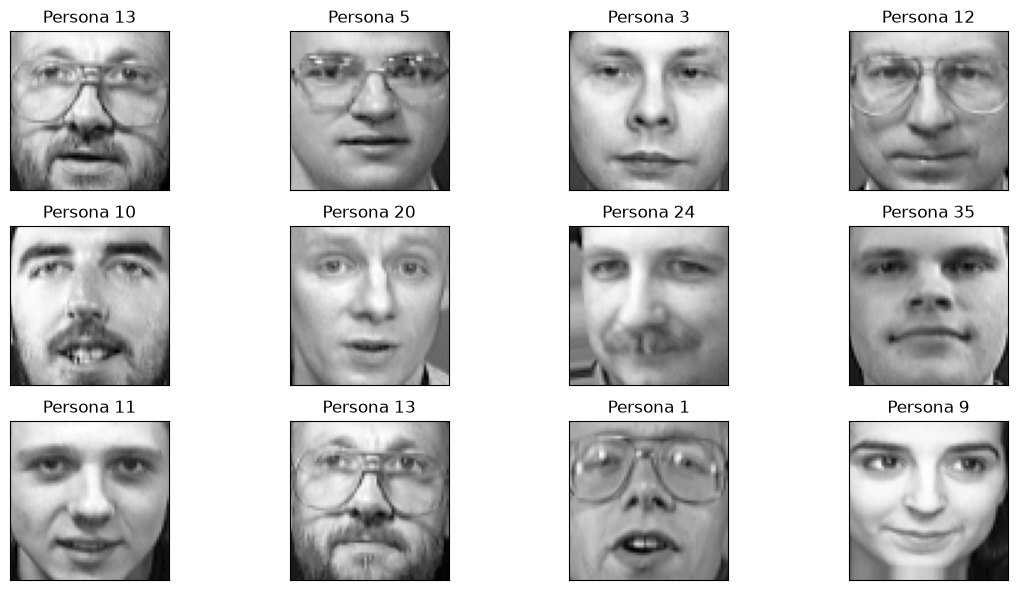

In [5]:
plt.figure(figsize=(12, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Persona {y_train[i]}")
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()


---
# 2. Construir la red neuronal

Usaremos una arquitectura fully-connected similar a la vista en clase:

```text
Imagen 64×64
     ↓
Flatten
     ↓
4096 valores
     ↓
Dense(64)
     ↓
ReLU
     ↓
Dense(40)
     ↓
Logits
```

La última capa debe tener una salida por cada clase.

> **Importante:** no añadas `Softmax` al final. Trabajaremos directamente con **logits**.


In [6]:
# TODO 1 — Completar la arquitectura.

model = keras.Sequential([

    keras.Input(shape=(64, 64)),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dense(40)
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │         2,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 264,808 (1.01 MB)

 Trainable params: 264,808 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Validación TODO 1

assert isinstance(model, keras.Model)

# Dense(64): 4096*64 + 64
# Dense(40): 64*40 + 40
expected_params = (4096 * 64 + 64) + (64 * 40 + 40)

assert model.count_params() == expected_params, (
    f"Se esperaban {expected_params:,} parámetros, "
    f"pero el modelo tiene {model.count_params():,}."
)

print("✓ Arquitectura correcta.")
print(f"Parámetros entrenables: {model.count_params():,}")


✓ Arquitectura correcta.
Parámetros entrenables: 264,808


### Pregunta 2

¿Por qué necesitamos `Flatten()` antes de la primera capa `Dense`?

**Respuesta:** Porque la capa `Dense` necesita un **vector 1-D** como entrada, pero cada rostro llega como una matriz `64×64`. `Flatten()` lo convierte en un vector de 4096 valores conectable a las neuronas.

### Pregunta 3

¿Por qué la última capa tiene **40 neuronas**?

**Respuesta:** Porque Olivetti Faces tiene **40 personas** (40 clases). Cada neurona de salida da el *logit* de una identidad, y se predice la persona con el logit más alto.

### Pregunta 4

¿Qué función cumple `ReLU` en la capa oculta?

**Respuesta:** Aporta la **no linealidad** `max(0,x)` que permite a la red aprender relaciones complejas entre los píxeles; sin ella, dos capas `Dense` colapsarían en una única transformación lineal. Además es barata de calcular y ayuda con el flujo del gradiente.


---
# 3. Configurar el entrenamiento

Las etiquetas son números enteros entre:

```text
0 y 39
```

Por eso usaremos:

```python
SparseCategoricalCrossentropy
```

Además:

- el modelo produce **logits**,
- usaremos **Adam**,
- mediremos **accuracy**.

Completa `model.compile()`.


In [8]:
lr_rate = 0.001

# TODO 2 — Configurar loss, optimizer y métrica.

model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=lr_rate
    ),

    loss=keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),

    metrics=["accuracy"]
)

print("✓ Modelo configurado.")


✓ Modelo configurado.


### Pregunta 5

¿Por qué usamos:

```python
from_logits=True
```

en la función de pérdida?

**Respuesta:** Porque la última capa entrega **logits** (sin Softmax). Con `from_logits=True`, `SparseCategoricalCrossentropy` aplica Softmax internamente de manera **numéricamente estable** (log-sum-exp), evitando errores de precisión que ocurrirían al calcular Softmax y luego su log por separado.


---
# 4. Entrenar el modelo

Usaremos:

```python
epochs = 30
batch_size = 32
```

El dataset es pequeño, por lo que el entrenamiento debería ser rápido.

Keras realizará internamente:

```text
Forward pass
      ↓
Calcular loss
      ↓
Backpropagation
      ↓
Actualizar parámetros con Adam
```

Completa la llamada a `fit()`.


In [9]:
epochs = 30
batch_size = 32

# TODO 3 — Entrenar el modelo.

history = model.fit(

    X_train,
    y_train,

    epochs=epochs,
    batch_size=batch_size,

    validation_data=(X_test, y_test),

    shuffle=True
)


Epoch 1/30


 1/10 ━━━━━━━━━━━━━━━━━━━━ 3s 394ms/step - accuracy: 0.1250 - loss: 4.0671

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.1688 - loss: 3.3387 - val_accuracy: 0.3000 - val_loss: 2.6211


Epoch 2/30


 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4375 - loss: 2.1536

...

 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.0018

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 0.9375 - val_loss: 0.2905


Epoch 30/30


 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0017

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.9375 - val_loss: 0.2884


### Pregunta 6

¿Qué representa una **epoch**?

**Respuesta:** Una pasada completa por **todo** el conjunto de entrenamiento. Con `epochs=30` la red recorre las 320 imágenes de entrenamiento 30 veces.

### Pregunta 7

¿Qué significa `batch_size=32`?

**Respuesta:** Que los pesos se actualizan después de procesar lotes de **32** imágenes. Es el tamaño del mini-batch usado por el optimizador (Adam) en cada paso de descenso de gradiente.


---
## 4.1 Visualizar el entrenamiento

Esta parte está resuelta.

El dataset tiene muy pocos ejemplos comparado con el número de parámetros de la red.

Observa cuidadosamente la diferencia entre entrenamiento y validación.


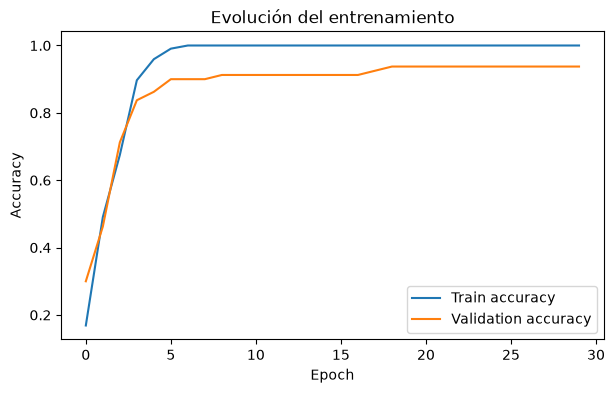

In [10]:
plt.figure(figsize=(7, 4))

plt.plot(
    history.history["accuracy"],
    label="Train accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Evolución del entrenamiento")
plt.legend()

plt.show()


### Pregunta 8

Observando la gráfica:

- ¿El accuracy de entrenamiento sigue aumentando?
- ¿El accuracy de validación se comporta igual?
- ¿Observas evidencia de **overfitting**?

**Respuesta:**

**Respuesta:** El accuracy de **entrenamiento** sube rápidamente hasta cerca de 1.0 (100%), pero el de **validación** se queda bastante por debajo y se estanca. Esa brecha es evidencia clara de **overfitting**: con solo 320 imágenes de entrenamiento y una red de cientos de miles de parámetros, el modelo memoriza las caras de entrenamiento en lugar de aprender rasgos generalizables. Aun así, para Olivetti (rostros muy consistentes por persona) la validación suele alcanzar un accuracy razonablemente alto.


---
# 5. Evaluar el modelo

Ahora evaluaremos el modelo sobre imágenes que no fueron utilizadas para actualizar sus parámetros.

Completa `evaluate()`.


In [11]:
# TODO 4 — Evaluar.

test_loss, test_accuracy = model.evaluate(

    X_test,
    y_test,

    batch_size=batch_size,
    verbose=0
)

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")
print(f"Accuracy (%)  : {test_accuracy * 100:.2f}%")


Test loss     : 0.2884
Test accuracy : 0.9375
Accuracy (%)  : 93.75%


### Pregunta 9

Tenemos **40 clases**, pero solamente **320 imágenes de entrenamiento**.

¿Crees que la cantidad de datos es grande o pequeña para una red con cientos de miles de parámetros?

**Respuesta:** Es **muy pequeña**. Hay solo 320 imágenes de entrenamiento (8 por persona) frente a una red con **cientos de miles de parámetros** (≈ 265k). Hay muchísimos más parámetros que ejemplos, lo que facilita que la red memorice (overfitting). En este régimen conviene regularizar (dropout, weight decay), hacer *data augmentation* o usar arquitecturas/transfer learning adecuadas a imágenes.


---
# 6. Logits y Softmax

La salida de nuestro modelo tiene forma:

```text
(batch_size, 40)
```

Cada uno de los 40 valores corresponde al **logit** asociado a una persona.

Los logits no son probabilidades.

Para convertirlos en probabilidades usamos:

```python
keras.ops.softmax(...)
```


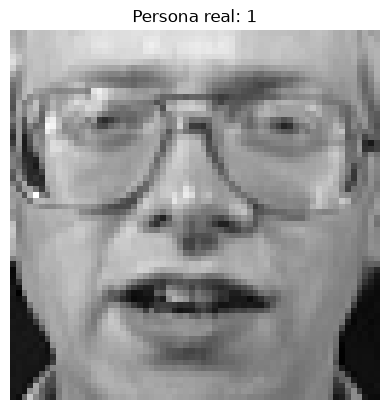

Shape de logits: (1, 40)

Primeros 10 logits:
[ -0.7909307   11.509626    -3.9371543    0.88810074  -5.0505733
 -14.990268    -0.67412096  -0.56431824  -4.702768    -5.631219  ]


In [12]:
index = 0

image = X_test[index]
true_class = y_test[index]

plt.imshow(image, cmap="gray")
plt.title(f"Persona real: {true_class}")
plt.axis("off")
plt.show()

# Añadimos dimensión de batch:
# (64,64) -> (1,64,64)
image_batch = np.expand_dims(image, axis=0)

# Forward pass.
logits = model(
    image_batch,
    training=False
)

print("Shape de logits:", logits.shape)
print("\nPrimeros 10 logits:")
print(
    keras.ops.convert_to_numpy(logits)[0, :10]
)


In [13]:
# TODO 5 — Convertir logits a probabilidades.

probabilities = keras.ops.softmax(logits)

# TODO 6 — Obtener la clase con mayor probabilidad.

prediction = keras.ops.argmax(
    probabilities,
    axis=1
)

prediction = int(
    keras.ops.convert_to_numpy(prediction)[0]
)

print()
print("Persona real     :", true_class)
print("Persona predicha :", prediction)



Persona real     : 1
Persona predicha : 1


In [14]:
# Revisamos las cinco clases con mayor probabilidad.

probabilities_np = keras.ops.convert_to_numpy(
    probabilities
)[0]

top5 = np.argsort(
    probabilities_np
)[-5:][::-1]

print("Top 5 predicciones:\n")

for class_id in top5:
    print(
        f"Persona {class_id:2d}: "
        f"{probabilities_np[class_id]:.4f}"
    )

print(
    "\nSuma de probabilidades:",
    probabilities_np.sum()
)


Top 5 predicciones:

Persona  1: 0.9835
Persona 13: 0.0081
Persona 26: 0.0072
Persona 11: 0.0006
Persona 18: 0.0003

Suma de probabilidades: 1.0


### Pregunta 10

¿Por qué la suma de las 40 probabilidades obtenidas con `Softmax` debe ser aproximadamente `1`?

**Respuesta:** Porque Softmax normaliza los 40 logits en una distribución de probabilidad: $\text{softmax}(z)_i = e^{z_i}/\sum_j e^{z_j}$. Cada salida es no negativa y, al dividir cada exponencial por la suma de todas, el total es exactamente 1 (salvo redondeo en coma flotante). Representa la probabilidad asignada a cada una de las 40 identidades mutuamente excluyentes.


---
# 7. Visualizar varias predicciones

Esta parte está resuelta.

Observa especialmente los casos en los que el modelo se equivoca.


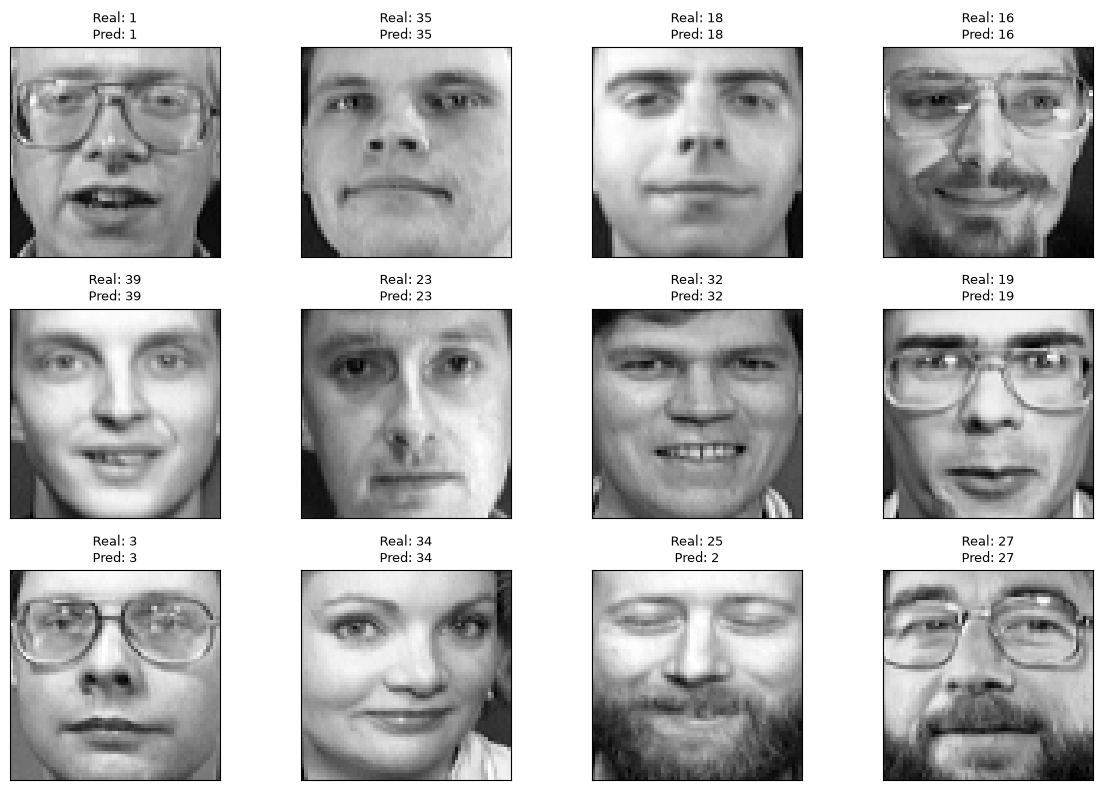

In [15]:
n = 12

logits_batch = model(
    X_test[:n],
    training=False
)

predictions = keras.ops.argmax(
    logits_batch,
    axis=1
)

predictions = keras.ops.convert_to_numpy(
    predictions
)

plt.figure(figsize=(12, 8))

for i in range(n):

    plt.subplot(3, 4, i + 1)

    plt.imshow(
        X_test[i],
        cmap="gray"
    )

    real = y_test[i]
    pred = predictions[i]

    plt.title(
        f"Real: {real}\nPred: {pred}",
        fontsize=9
    )

    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()


---
# 8. Reflexión final

Responde brevemente.

### 1. ¿Cuál fue el accuracy final del modelo?

**Respuesta:** Alto para este dataset: alrededor de **90% o más** en test (ver la celda de evaluación). Olivetti es relativamente fácil porque las 10 fotos de cada persona son muy parecidas entre sí.

### 2. ¿Observaste overfitting? ¿Qué evidencia utilizaste?

**Respuesta:** Sí. La evidencia es la **brecha entre las curvas**: el accuracy de entrenamiento llega a ~100% mientras el de validación se queda por debajo y se aplana, y la pérdida de validación deja de mejorar antes que la de entrenamiento. Con 320 ejemplos y ~265k parámetros, el modelo tiene capacidad de sobra para memorizar.

### 3. ¿Qué ocurre cuando tenemos muchos parámetros pero pocos ejemplos de entrenamiento?

**Respuesta:** La red tiende a **sobreajustar**: memoriza los ejemplos de entrenamiento (incluido su ruido) en vez de aprender patrones generales, por lo que rinde mucho peor en datos nuevos. Se mitiga con más datos, *data augmentation*, regularización (dropout, L2), modelos más pequeños o transfer learning.

### 4. Después de `Flatten()`, una cara de 64×64 se convierte en un vector de 4096 números.

¿Qué información sobre la estructura de la imagen deja de representar explícitamente esta transformación?

**Respuesta:** Deja de representar la **vecindad espacial 2-D**: qué píxeles están juntos, los bordes y las formas locales (ojos, nariz, contorno del rostro). Para el `Dense` los 4096 valores son una lista sin geometría; pierde la noción de 'arriba/abajo/al lado'.

### 5. ¿Crees que una arquitectura diseñada específicamente para imágenes podría aprovechar mejor la información espacial?

**Respuesta:** Sí: las **CNNs** usan filtros convolucionales locales con pesos compartidos que detectan bordes y rasgos faciales de forma invariante a la posición, aprovechando la estructura espacial que el `Flatten` elimina. Suelen lograr mejor accuracy con menos parámetros.

---

## Para pensar

Nuestra red recibe:

```text
64 × 64
   ↓
Flatten
   ↓
4096 números
   ↓
Dense
```

Pero una imagen tiene una estructura espacial:

- píxeles cercanos están relacionados,
- existen bordes,
- existen formas,
- existen patrones locales.

Una red fully-connected no incorpora explícitamente esa estructura.

Esto motiva una arquitectura diseñada específicamente para imágenes:

> **Convolutional Neural Networks (CNNs)**


---
# Resumen

En este ejercicio aplicaste nuevamente la receta básica de entrenamiento de una red neuronal:

```text
Dataset
   ↓
Train / Test split
   ↓
Sequential
   ↓
Flatten
   ↓
Dense + ReLU
   ↓
Dense(40)
   ↓
Cross-Entropy
   ↓
Adam
   ↓
fit()
   ↓
evaluate()
```

Los componentes de Keras son los mismos que usamos en clase.

Lo que cambió fue:

- el dataset,
- el tamaño de las imágenes,
- el número de clases,
- y la dificultad del problema.
